In [43]:
# Import dependencies
import numpy as np
import pandas as pd
import os

In [ ]:
# Load in the dataset
df = pd.read_csv('../../datasets/Salary_dataset.csv')

X = df['YearsExperience'].to_numpy()
y = df['Salary'].to_numpy()

In [45]:
# Hyperparameters
learning_rate = 0.01    # How large of steps to take

In [46]:
# General MSE loss function
def mse_loss(targets: np.ndarray, preds: np.ndarray):
    return (np.sum((preds - targets) ** 2)) / len(targets)

In [47]:
class UnivariateLinearRegression:
    def __init__(self, learning_rate):
        self.lr = learning_rate
        self.w = 0
        self.b = 0

    # Update weights with mse loss
    def update_weights(self, x: np.ndarray, y: np.ndarray):
        # Length of examples
        n = len(y)

        # Get predictions
        y_hat = self.w * x + self.b

        # Update (Calc derivatives then new equation)
        dw = (np.sum((y_hat - y) * x)) / n
        db = (np.sum(y_hat - y)) / n

        self.w -= self.lr * dw
        self.b -= self.lr * db

    # Fit the function to data
    def fit(self, X: np.ndarray, y: np.ndarray, epochs=1000, verbose=False):
        # Update weights until reach convergence or ran a set number of times (epislon)
        for i in range(epochs):
            # Update the weights
            self.update_weights(X, y)

            # Report loss
            loss = mse_loss(y, self.w * X + self.b)

            if verbose:
                print(f'[{i+1}]: Loss: {loss:.4f}')

In [48]:
# Test model
model = UnivariateLinearRegression(learning_rate)
model.fit(X, y, 1000, True)

[1]: Loss: 2595926437.1272
[2]: Loss: 1088095302.1513
[3]: Loss: 506034775.8702
[4]: Loss: 281176405.1170
[5]: Loss: 194142695.4554
[6]: Loss: 160288629.3643
[7]: Loss: 146954614.1624
[8]: Loss: 141539208.3967
[9]: Loss: 139180244.3154
[10]: Loss: 138001689.6768
[11]: Loss: 137279688.2339
[12]: Loss: 136734941.4468
[13]: Loss: 136259679.7518
[14]: Loss: 135812316.6569
[15]: Loss: 135376801.8853
[16]: Loss: 134946938.1190
[17]: Loss: 134520329.7415
[18]: Loss: 134096048.0100
[19]: Loss: 133673730.1813
[20]: Loss: 133253231.9161
[21]: Loss: 132834493.1628
[22]: Loss: 132417486.4095
[23]: Loss: 132002196.7168
[24]: Loss: 131588614.0147
[25]: Loss: 131176730.1291
[26]: Loss: 130766537.6355
[27]: Loss: 130358029.4158
[28]: Loss: 129951198.4878
[29]: Loss: 129546037.9390
[30]: Loss: 129142540.9014
[31]: Loss: 128740700.5410
[32]: Loss: 128340510.0543
[33]: Loss: 127941962.6667
[34]: Loss: 127545051.6319
[35]: Loss: 127149770.2311
[36]: Loss: 126756111.7735
[37]: Loss: 126364069.5955
[38]: Lo

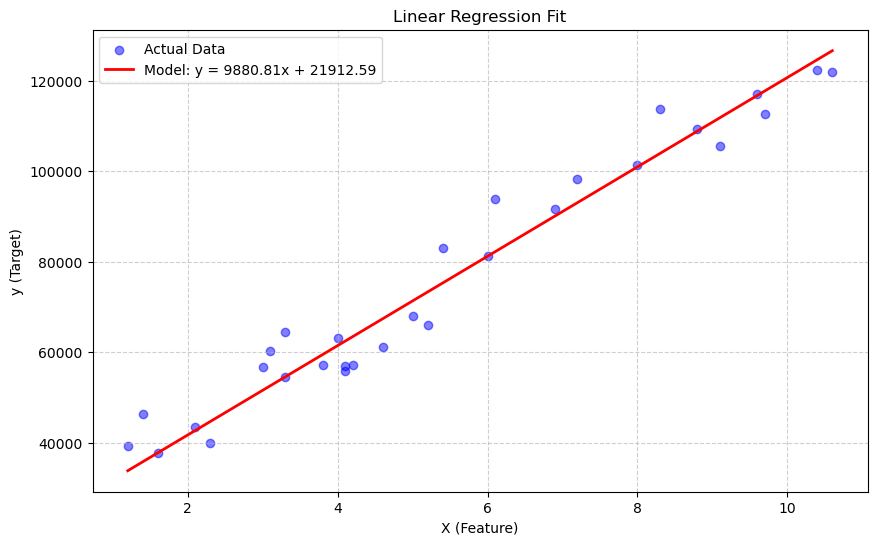

In [49]:
import matplotlib.pyplot as plt

def plot_regression_line(X, y, model):
    plt.figure(figsize=(10, 6))
    
    # Plot the actual data points
    plt.scatter(X, y, color='blue', label='Actual Data', alpha=0.5)
    
    # Calculate the line coordinates
    y_pred = model.w * X + model.b
    
    # Plot the regression line
    plt.plot(X, y_pred, color='red', linewidth=2, label=f'Model: y = {model.w:.2f}x + {model.b:.2f}')
    
    plt.title('Linear Regression Fit')
    plt.xlabel('X (Feature)')
    plt.ylabel('y (Target)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_regression_line(X, y, model)